<a href="https://colab.research.google.com/github/Escalada-Matthew/CPE-312/blob/main/HOA1_1_Escalada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 1.1 : Introduction to Machine Learning

Objective(s):

This activity aims to introduce how to use the different toolsets  in machine learning.

Intended Learning Outcomes (ILOs):
* Demonstrate how to use different toolsets in machine learning.
* Demonstrate how to import, manipulate and analyze data using pandas and numpy.
* Demonstrate how to visualize data in graphs using matplotlib and seaborn


Resources:
* Jupyter Notebook
* Iris_Data.csv


Procedure:

The iris data set will be used for this activity. It is a well-known data set containing iris species and sepal and petal measurements.

Import the libraries and the dataset

In [2]:
#import the libraries
import pandas as pd
import numpy as np

# import the dataset
data = pd.read_csv('Iris_Data.csv')
#check the content of the dataframe
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Determine the following:
* The number of data points (rows).
* The column names.
* The data types for each column.

In [3]:
#the number of datapoints
print(data.shape[0])

#the column names
print(data.columns.tolist())

#the data types for each column
print(data.dtypes)

150
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


Examine the species names and note that they all begin with 'Iris-'. Remove this portion of the name so the species name is shorter.

In [4]:
#remove the 'Iris-' portion of the name
data['species'] = data.species.str.replace('Iris-', '')
data.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Determine the following:
* The number of each species present.
* The mean, median, and quantiles and ranges (max-min) for each petal and sepal measurement.

In [5]:
#the number of each species present
data.species.value_counts()

# the mean, median and quartiles and ranges
stats_df = data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['mean','25%','50%','75%', 'range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df



,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000
range,3.600000,2.400,5.900000,2.400000


Calculate the following for each species in a separate dataframe:
* The mean of each measurement (sepal_length, sepal_width, petal_length, and petal_width).
* The median of each of these measurements.

In [6]:
# The mean calculation
data.groupby('species').mean()



,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [7]:
# The median calculation
data.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


In [8]:
from pprint import pprint

agg_dict = {field: ['mean', 'median'] for field in data.columns if field != 'species'}
agg_dict['petal_length'] = 'max'
pprint(agg_dict)
data.groupby('species').agg(agg_dict)

{'petal_length': 'max',
 'petal_width': ['mean', 'median'],
 'sepal_length': ['mean', 'median'],
 'sepal_width': ['mean', 'median']}


sepal_length        sepal_width        petal_length petal_width  \
                   mean median        mean median          max        mean   
species                                                                      
setosa            5.006    5.0       3.418    3.4          1.9       0.244   
versicolor        5.936    5.9       2.770    2.8          5.1       1.326   
virginica         6.588    6.5       2.974    3.0          6.9       2.026   

                   
           median  
species            
setosa        0.2  
versicolor    1.3  
virginica     2.0

Make a scatter plot of `sepal_length` vs `sepal_width` using Matplotlib. Label the axes and give the plot a title.

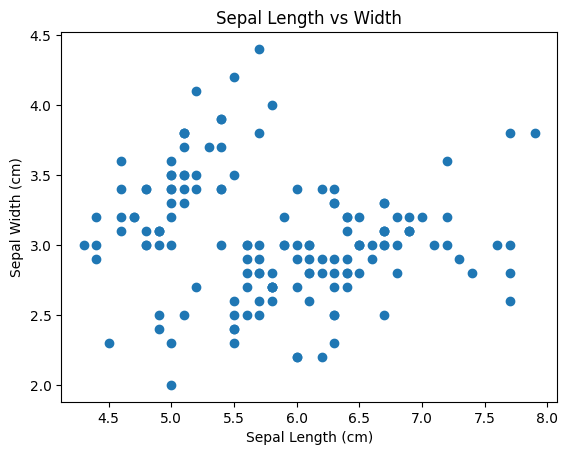

In [9]:
#Scatter plot of sepal_length versus sepal_width using Matplotlib

import matplotlib.pyplot as plt
%matplotlib inline
# A simple scatter plot with Matplotlib
ax = plt.axes()

ax.scatter(data.sepal_length, data.sepal_width)

# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');


Interpret the result of the scatter plot.

It shows the consistency of data points in the 2.5-3 cm range of the Sepal_Width, while Sepal_Length's data points shows consistency in the 5-6 cm range.

Make a histogram of any one of the four features. Label axes and title it as appropriate. What is the function of the histogram ?

The function of a histogram is to show the consistency of data

To show the frequency of the chosen data

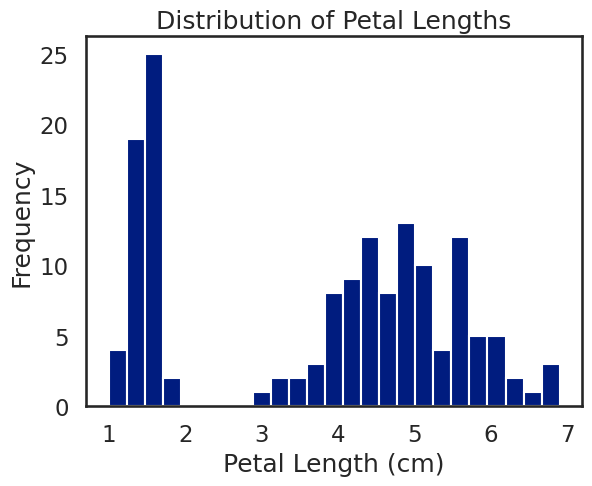

In [18]:
#histogram
ax = plt.axes()
ax.hist(data.petal_length, bins=25);

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

Make a boxplot of each petal and sepal measurement. What is the function of the boxplot?

Boxplot visualizes the five number summary of a data. Presenting the concise summary of a dataset's central tendency and spread.

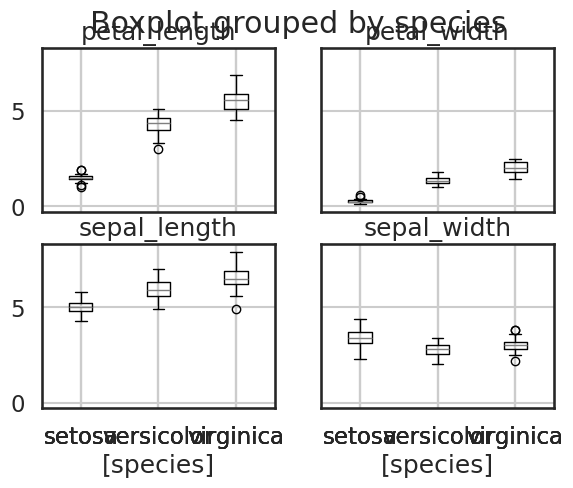

In [20]:
#boxplot
data.boxplot(by='species');

Make a single boxplot where the features are separated in the x-axis and species are colored with different hues.

In [12]:
#single boxplot
plot_data = (data
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()

,species,measurement,size
0,setosa,sepal_length,5.1
1,setosa,sepal_width,3.5
2,setosa,petal_length,1.4
3,setosa,petal_width,0.2
4,setosa,sepal_length,4.9


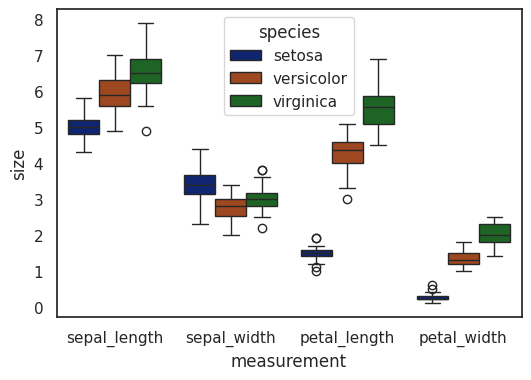

In [13]:
import seaborn as sns
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size',
            hue='species', data=plot_data);

Make a pairplot with Seaborn to examine the correlation between each of the measurements.

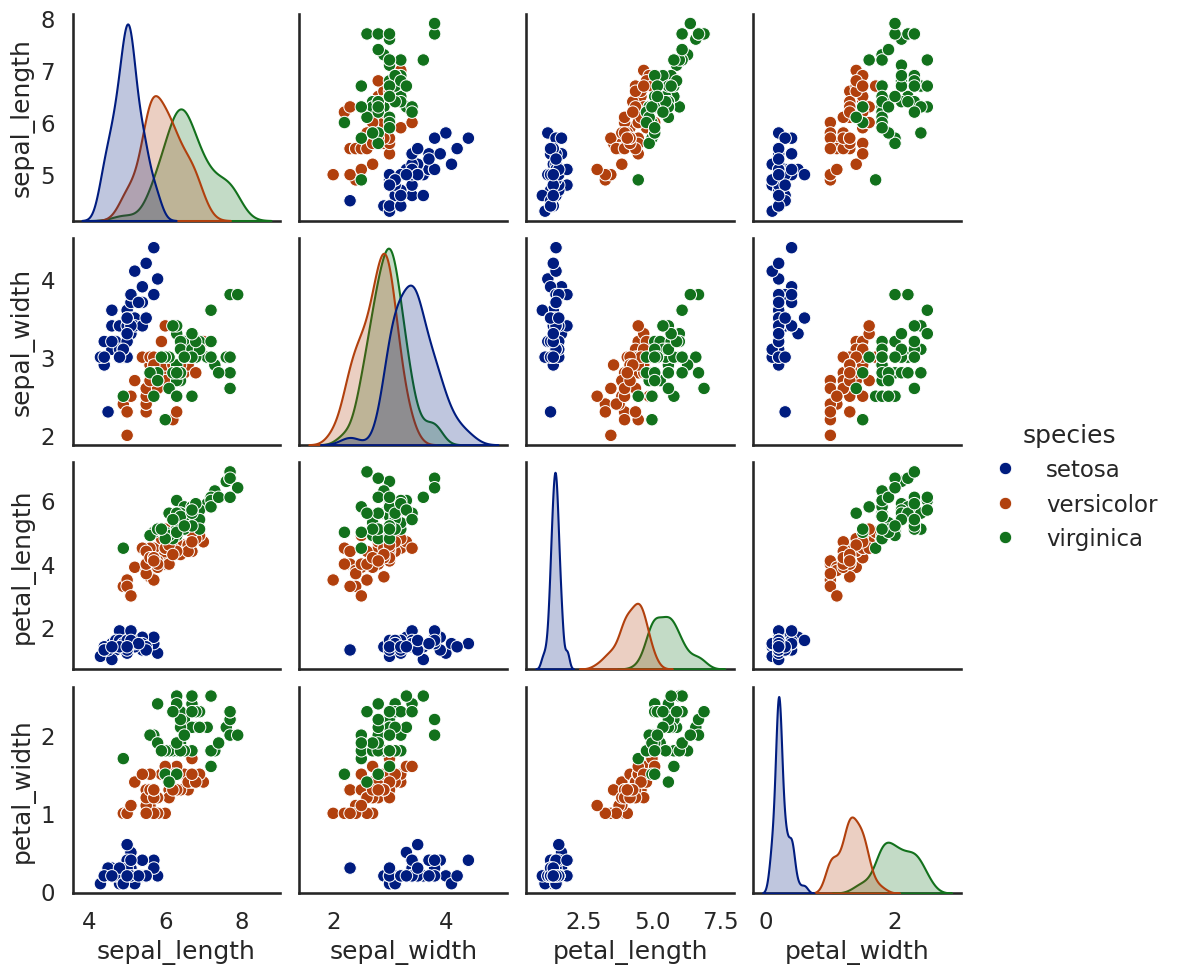

In [14]:
#pair plot
sns.set_context('talk')
sns.pairplot(data, hue='species');



Interpret the result of correlation using the pairplot

It shows that compared to the species Setosa, Versicolor and Virginica follow similar paths but Virginica maintains a larger dimension.

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values.
* Perform descriptive statistics such as mean, median and mode
* Compare and analyze your data using data visualization

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [26]:
print("Column Names")
print(df.columns.tolist())

print("\nData Info")
df.info()

print("\nData Preview")
display(df.head(15))


Column Names
['Date_Time_PH', 'Latitude', 'Longitude', 'Depth_In_Km', 'Magnitude', 'Location', 'Specific_Location', 'General_Location']

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135281 entries, 0 to 135280
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date_Time_PH       135281 non-null  object 
 1   Latitude           135257 non-null  float64
 2   Longitude          135257 non-null  float64
 3   Depth_In_Km        135280 non-null  object 
 4   Magnitude          135281 non-null  float64
 5   Location           135281 non-null  object 
 6   Specific_Location  135281 non-null  object 
 7   General_Location   135281 non-null  object 
dtypes: float64(3), object(5)
memory usage: 8.3+ MB

Data Preview


,Date_Time_PH,Latitude,Longitude,Depth_In_Km,Magnitude,Location,Specific_Location,General_Location
0,2026-07-06 07:35:00,5.71,124.73,27.0,2.0,033 km S 22° E of Kiamba (Sarangani),Kiamba,Sarangani
1,2026-07-06 06:56:00,5.25,125.35,30.0,2.7,020 km S 25° W of Balut Island (Municipality O...,Balut Island,Davao Occidental
2,2026-07-06 06:46:00,5.32,125.32,30.0,2.1,015 km S 49° W of Balut Island (Municipality O...,Balut Island,Davao Occidental
3,2026-07-06 06:20:00,5.20,125.34,2.0,2.9,025 km S 22° W of Balut Island (Municipality O...,Balut Island,Davao Occidental
4,2026-07-06 06:00:00,5.48,125.09,1.0,2.1,037 km N 79° W of Balut Island (Municipality O...,Balut Island,Davao Occidental
5,2026-07-06 05:42:00,9.44,126.42,19.0,2.2,031 km N 54° E of Cortes (Surigao Del Sur),Cortes,Surigao Del Sur
6,2026-07-06 05:23:00,5.37,125.31,54.0,2.0,013 km S 71° W of Balut Island (Municipality O...,Balut Island,Davao Occidental
7,2026-07-06 05:19:00,5.51,125.10,25.0,1.2,036 km S 18° W of Glan (Sarangani),Glan,Sarangani
8,2026-07-06 05:19:00,5.94,125.38,12.0,1.7,011 km S 74° E of Malapatan (Sarangani),Malapatan,Sarangani
9,2026-07-06 05:14:00,5.97,125.39,22.0,2.1,012 km S 89° E of Malapatan (Sarangani),Malapatan,Sarangani


In [30]:
df.columns = df.columns.str.strip()

cols_to_drop = ['Latitude', 'Longitude', 'Depth_In_Km']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

In [36]:
print("Statistical Summary Analysis")
# I used describe() to find the mean, min, max, and percentiles for core variables
summary_stats = df[['Magnitude']].describe()
display(summary_stats)

Statistical Summary Analysis


,Magnitude
count,135281.000000
mean,2.493663
std,0.704175
min,1.000000
25%,2.000000
50%,2.400000
75%,2.900000
max,7.800000


In [55]:
loc_count = df['General_Location'].value_counts()
loc_count

,count
General_Location,
Surigao Del Sur,17182
Davao Occidental,11263
Davao Oriental,11169
Surigao Del Norte,9108
Batangas,6505
...,...
Dumaguete City,1
General Luna,1
San Mariano,1


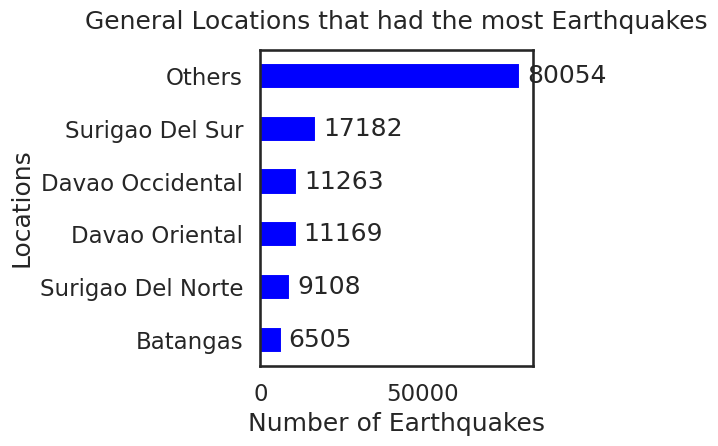

In [68]:
top5 = loc_count.head(5)
others_sum = loc_count.iloc[5:].sum()
final_loc = top5._append(pd.Series({'Others': others_sum}))

final_loc_sorted = final_loc.sort_values(ascending=True)
ax = final_loc_sorted.plot(kind='barh', color='blue')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)
plt.xlabel('Number of Earthquakes')
plt.ylabel('Locations')
plt.title('General Locations that had the most Earthquakes', pad=15)
plt.tight_layout()
plt.show()

This Histogram shows that the Top 5 locations had the most amount of Earthquakes in the Philippines. The rest may seem like higher, but it is because all of the other locations were combined into a single variable. Others contains 136 locations.

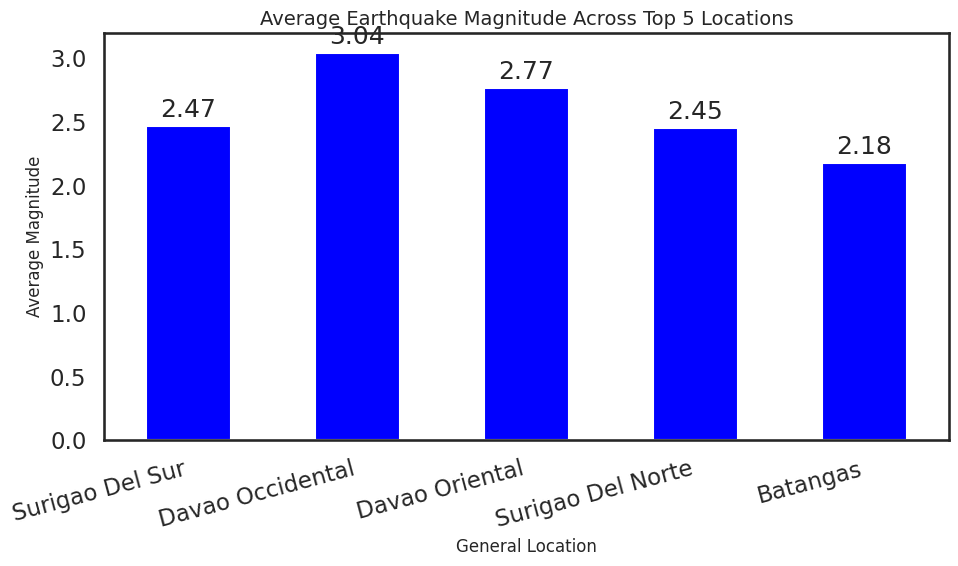

In [70]:
top_5 = df['General_Location'].value_counts().head(5).index
filtered_df = df[df['General_Location'].isin(top_5)]
mean_magnitudes = filtered_df.groupby('General_Location')['Magnitude'].mean().reindex(top_5)
plt.figure(figsize=(10, 6))
ax = mean_magnitudes.plot(kind='bar', color='blue')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Average Earthquake Magnitude Across Top 5 Locations', fontsize=14)
plt.xlabel('General Location', fontsize=12)
plt.ylabel('Average Magnitude', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

This Bar Plot shows the Average(Mean) Earthquake Magnitude of the Top Locations. It shows that Davao occidental often experiences stronger Earthquakes.